<a href="https://colab.research.google.com/github/trozmarynowski/Football-Players-Stats-Analysis-2025-2026-Season-/blob/main/Kopia_notatnika_Kopia_notatnika_Untitled93.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:

!pip install kagglehub

import kagglehub
import os
import pandas as pd


os.environ['KAGGLE_API_TOKEN'] = "KGAT_121a6fb05d0e8602aa5943bf4639a854"
sciezka = kagglehub.dataset_download("hubertsidorowicz/football-players-stats-2025-2026")


nazwa_pliku = os.listdir(sciezka)[0]
pelna_sciezka = sciezka + "/" + nazwa_pliku
tabela_pilkarze = pd.read_csv(pelna_sciezka)


tabela_pilkarze = tabela_pilkarze.dropna(subset=['Age'])
tabela_pilkarze = tabela_pilkarze.fillna(0)


print("Suma wszystkich braków w tabeli po czyszczeniu:", tabela_pilkarze.isnull().sum().sum())
print("Aktualny rozmiar tabeli (wiersze, kolumny):", tabela_pilkarze.shape)

Using Colab cache for faster access to the 'football-players-stats-2025-2026' dataset.
Suma wszystkich braków w tabeli po czyszczeniu: 0
Aktualny rozmiar tabeli (wiersze, kolumny): (2730, 102)


In [22]:
tabela_pilkarze.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,25.0,2000.0,30,24,...,1,0,0,17,43,5,35,13,22,0
1,2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,2,1,...,0,0,0,2,1,0,3,2,2,0
2,3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20.0,2006.0,20,4,...,0,0,0,5,3,2,26,3,3,0
3,4,Himad Abdelli,dz ALG,"FW,MF",Marseille,fr Ligue 1,26.0,1999.0,5,0,...,1,0,0,3,0,0,1,1,1,0
4,5,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,1,0,0,16,12,1,9,13,17,0


In [23]:

kolumny_do_wyswietlenia = ['Player', 'Squad', 'Age', 'Gls']
wybrane_dane = tabela_pilkarze[kolumny_do_wyswietlenia]


top_10_strzelcow = wybrane_dane.sort_values(by='Gls', ascending=False).head(10)


print(top_10_strzelcow)

                  Player            Squad   Age  Gls
1265          Harry Kane    Bayern Munich  32.0   31
1630       Kylian Mbappé      Real Madrid  27.0   23
1055      Erling Haaland  Manchester City  25.0   22
2480         Igor Thiago        Brentford  24.0   19
1770        Vedat Muriqi         Mallorca  31.0   19
2553         Deniz Undav        Stuttgart  29.0   18
1964  Joaquín Panichelli       Strasbourg  23.0   16
1592    Lautaro Martínez            Inter  28.0   16
1004     Mason Greenwood        Marseille  24.0   15
378         Ante Budimir          Osasuna  34.0   15


/tmp/ipykernel_7586/220388248.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  wykres = sns.barplot(x='Player', y='Gls', data=top_10_strzelcow, palette='viridis')


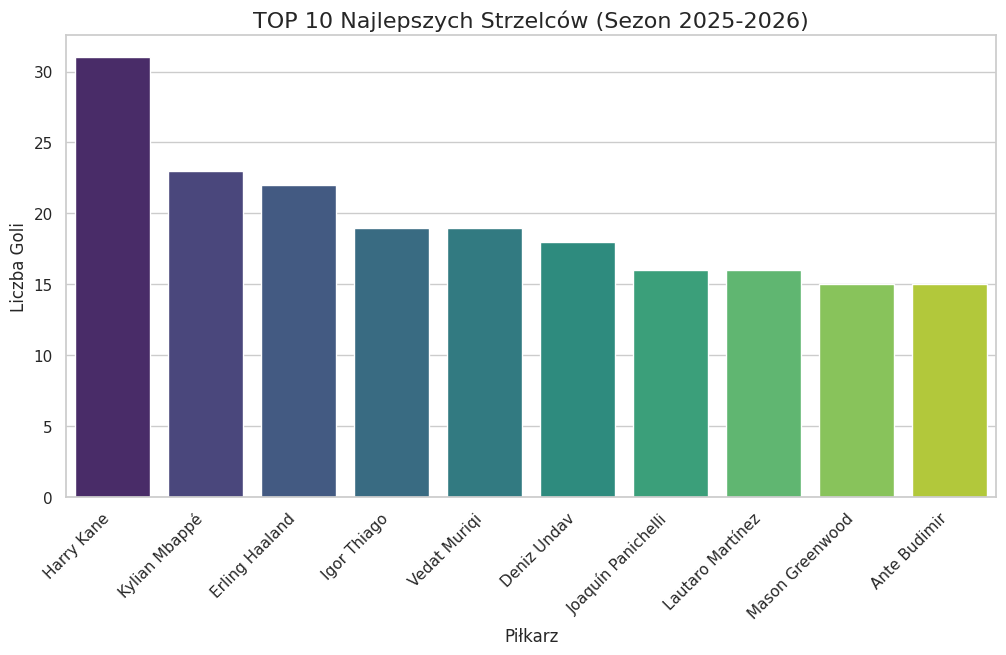

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


plt.figure(figsize=(12, 6))


wykres = sns.barplot(x='Player', y='Gls', data=top_10_strzelcow, palette='viridis')

plt.title('TOP 10 Najlepszych Strzelców (Sezon 2025-2026)', fontsize=16)
plt.xlabel('Piłkarz', fontsize=12)
plt.ylabel('Liczba Goli', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.show()

In [25]:
lista_kolumn = tabela_pilkarze.columns.tolist()
lista_kolumn

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Comp',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'G+A-PK',
 'Rk_stats_keeper',
 'Nation_stats_keeper',
 'Pos_stats_keeper',
 'Comp_stats_keeper',
 'Age_stats_keeper',
 'Born_stats_keeper',
 'MP_stats_keeper',
 'Starts_stats_keeper',
 'Min_stats_keeper',
 '90s_stats_keeper',
 'GA',
 'GA90',
 'SoTA',
 'Saves',
 'Save%',
 'W',
 'D',
 'L',
 'CS',
 'CS%',
 'PKatt_stats_keeper',
 'PKA',
 'PKsv',
 'PKm',
 'Rk_stats_shooting',
 'Nation_stats_shooting',
 'Pos_stats_shooting',
 'Comp_stats_shooting',
 'Age_stats_shooting',
 'Born_stats_shooting',
 '90s_stats_shooting',
 'Gls_stats_shooting',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'PK_stats_shooting',
 'PKatt_stats_shooting',
 'Rk_stats_playing_time',
 'Nation_stats_playing_time',
 'Pos_stats_playing_time',
 'Comp_stats_playing_time',
 'Age_stats_playing_time',
 'Born_stats_playing_time',
 'MP_st

In [26]:
# Wygląda na to, że autor tego zbioru danych oparł się na klasycznych
# statystykach bez danych takich jak wskaznik xG oraz xA. Zamiast porownania
# tych wartosci aby ocenic czy zawodnik regularnie dochodzi do dobrych sytuacji
# strzeleckich i czy wykańcza je lepiej, czy gorzej niż przeciętny gracz
# uzyje wskaznika G/Sot(Gole na strzal celny - Goals per shot on target).
# Pokaże to kto potrzebuje najmniej celnych strzalow aby zdobyc bramke.

In [27]:
# Minimum 10 pelnych rozegranych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# Minimum 10 celnych strzałów w sezonie

regularni_gracze = regularni_gracze[regularni_gracze['SoT'] >= 10]


kolumny_skutecznosc = ['Player', 'Squad', 'Gls', 'SoT', 'G/SoT']


najbardziej_skuteczni = regularni_gracze[kolumny_skutecznosc].sort_values(by='G/SoT', ascending=False).head(30)


print(" TOP 10 NAJBARDZIEJ SKUTECZNYCH ZAWODNIKÓW (Gole / Strzał Celny) ")
print(najbardziej_skuteczni)

 TOP 10 NAJBARDZIEJ SKUTECZNYCH ZAWODNIKÓW (Gole / Strzał Celny) 
                     Player                Squad  Gls  SoT  G/SoT
2424             Pavel Šulc                 Lyon   11   16   0.69
739               Hugo Duro             Valencia    9   12   0.67
1069       Hákon Haraldsson                Lille    7   11   0.64
226           Thierno Barry              Everton    6   10   0.60
769            Hugo Ekitike            Liverpool   11   19   0.58
961            Martial Godo           Strasbourg    8   14   0.57
2646          Danny Welbeck             Brighton   12   20   0.55
648   Kiernan Dewsbury-Hall              Everton    6   11   0.55
2493          Malik Tillman           Leverkusen    6   11   0.55
784            Breel Embolo               Rennes    7   13   0.54
2062         Grischa Prömel           Hoffenheim    7   13   0.54
1054        Viktor Gyökeres              Arsenal   11   17   0.53
931              Yann Gboho             Toulouse    8   15   0.53
637       

In [28]:
#Tworze wskaznik Asysty na 90 minut (Ast_per_90).
#Dzieki temu zidentyfikuje najlepszych kreatorow gry.

In [29]:
# Minimum 10 pelnych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# 2. Tworze nową statystykę: dziele liczbę asyst przez liczbę rozegranych pełnych meczów (90s)
regularni_gracze['Ast_per_90'] = regularni_gracze['Ast'] / regularni_gracze['90s']

kolumny_kreatorzy = ['Player', 'Squad', 'Ast', '90s', 'Ast_per_90']


najlepsi_kreatorzy = regularni_gracze[kolumny_kreatorzy].sort_values(by='Ast_per_90', ascending=False).head(30)


print("TOP 10 NAJLEPSZYCH KREATORÓW GRY (Asysty na 90 minut) ")
print(najlepsi_kreatorzy)

TOP 10 NAJLEPSZYCH KREATORÓW GRY (Asysty na 90 minut) 
                    Player                Squad  Ast   90s  Ast_per_90
1901         Michael Olise        Bayern Munich   18  22.3    0.807175
2204        Julian Ryerson             Dortmund   12  19.5    0.615385
833        Bruno Fernandes       Manchester Utd   16  27.0    0.592593
509           Rayan Cherki      Manchester City    8  14.5    0.551724
494           Fares Chaïbi  Eintracht Frankfurt    9  16.5    0.545455
1465          Fermin López            Barcelona    8  15.2    0.526316
680       Federico Dimarco                Inter   13  25.8    0.503876
672              Luis Díaz        Bayern Munich   11  24.0    0.458333
1725        Afonso Moreira                 Lyon    6  13.1    0.458015
958           Serge Gnabry        Bayern Munich    6  13.5    0.444444
2727       Martin Ødegaard              Arsenal    5  12.0    0.416667
2158       Jesus Rodríguez                 Como    7  17.1    0.409357
1987                 P

In [30]:
# Min. 10 pelnych meczow
regularni_gracze = tabela_pilkarze[tabela_pilkarze['90s'] >= 10].copy()

# 2. Tworze nową kolumnę: suma kluczowych akcji defensywnych
regularni_gracze['Akcje_Defensywne'] = regularni_gracze['Int'] + regularni_gracze['TklW']

# 3. Podzielilem wynik przez rozegrane mecze, aby uzyskać średnią na 90 minut gry
regularni_gracze['Def_per_90'] = regularni_gracze['Akcje_Defensywne'] / regularni_gracze['90s']

# 4. Wybieram kluczowe kolumny do wyświetlenia (dodaje też 'Pos', czyli pozycję gracza na boisku)
kolumny_defensywa = ['Player', 'Squad', 'Pos', 'Akcje_Defensywne', 'Def_per_90']


najlepsi_w_defensywie = regularni_gracze[kolumny_defensywa].sort_values(by='Def_per_90', ascending=False).head(30)


print("TOP 10 ZAWODNIKÓW Z NAJWIĘKSZYM ZAANGAŻOWANIEM W DEFENSYWĘ (Akcje na 90 minut) ")
print(najlepsi_w_defensywie)

TOP 10 ZAWODNIKÓW Z NAJWIĘKSZYM ZAANGAŻOWANIEM W DEFENSYWĘ (Akcje na 90 minut) 
                      Player                Squad    Pos  Akcje_Defensywne  \
1168          Tim Iroegbunam              Everton     MF                55   
1600         Patrizio Masini                Genoa     MF                58   
88            Sergi Altimira           Real Betis     MF                49   
894      Roberto Gagliardini        Hellas Verona     MF                80   
2420           Gabriel Suazo              Sevilla  DF,MF                72   
50             Lucas Ahijado               Oviedo     DF                42   
411           Moisés Caicedo              Chelsea     MF                94   
633          Pape Demba Diop             Toulouse     MF                41   
424            Lamine Camara               Monaco     MF                63   
442          Nicolás Capaldo         Hamburger SV  DF,MF                65   
261          Jobe Bellingham             Dortmund     MF      

In [31]:
from sklearn.preprocessing import StandardScaler

dane_liczbowe = tabela_pilkarze.select_dtypes(include=['float64', 'int64']).copy()

skaler = StandardScaler()
dane_znormalizowane = skaler.fit_transform(dane_liczbowe)
print(f"Rozmiar danych przekazywanych do AI: {dane_znormalizowane.shape}")

Rozmiar danych przekazywanych do AI: (2730, 81)


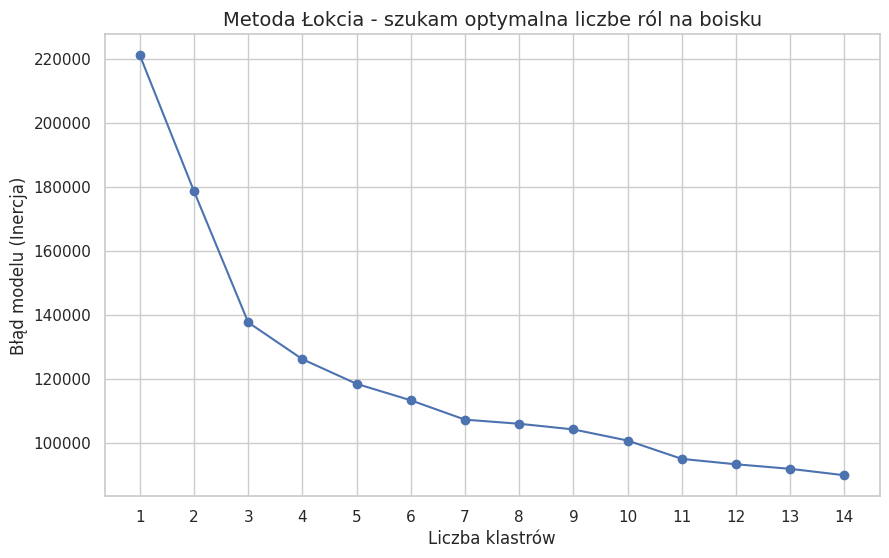

In [32]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

znieksztalcenia = []
zakres_klastrow = range(1, 15)

for i in zakres_klastrow:
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(dane_znormalizowane)
    znieksztalcenia.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(zakres_klastrow, znieksztalcenia, marker='o', linestyle='-', color='b')
plt.title('Metoda Łokcia - szukam optymalna liczbe ról na boisku', fontsize=14)
plt.xlabel('Liczba klastrów', fontsize=12)
plt.ylabel('Błąd modelu (Inercja)', fontsize=12)
plt.xticks(zakres_klastrow)
plt.grid(True)
plt.show()

In [33]:
from sklearn.cluster import KMeans

# 1. Tworzę i trenuje model z 6 klastrami
model_kmeans_ostateczny = KMeans(n_clusters=6, random_state=42)
tabela_pilkarze['Rola_AI'] = model_kmeans_ostateczny.fit_predict(dane_znormalizowane)

# 2. Dodaję brakujące statystyki do tabeli
tabela_pilkarze['Ast_per_90'] = tabela_pilkarze['Ast'] / tabela_pilkarze['90s'].replace(0, 0.1)
tabela_pilkarze['Akcje_Defensywne'] = tabela_pilkarze['Int'] + tabela_pilkarze['TklW']
tabela_pilkarze['Def_per_90'] = tabela_pilkarze['Akcje_Defensywne'] / tabela_pilkarze['90s'].replace(0, 0.1)

kolumny_do_profilu = ['Gls', 'Ast_per_90', 'Def_per_90', 'SoT']


profil_grup = tabela_pilkarze.groupby('Rola_AI')[kolumny_do_profilu].mean().round(2)


print("Średnie statystyki dla każdej z 6 wyodrębnionych ról na boisku:")
print(profil_grup)

Średnie statystyki dla każdej z 6 wyodrębnionych ról na boisku:
          Gls  Ast_per_90  Def_per_90    SoT
Rola_AI                                     
0        0.28        0.06        1.40   1.17
1        7.98        0.15        0.99  20.63
2        0.00        0.00        0.03   0.01
3        1.57        0.11        1.67   5.31
4        0.12        0.09        1.83   0.71
5        1.36        0.07        2.09   5.06


In [34]:
# 1. Wyciągam zawodników przypisanych do Klastra 0
napastnicy = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == 0]

# 2. Wyciągamy zawodników przypisanych do Klastra 5
defensywa = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == 5]

# 3. Wyświetlam 5 najlepszych napastników z ich grupy, sortując po golach
print(" ELITARNI NAPASTNICY (KLASTER 0) ⚽")
print(napastnicy[['Player', 'Squad', 'Gls', 'SoT']].sort_values(by='Gls', ascending=False).head())

# 4. Wyświetlam 5 najlepszych defensorów z ich grupy, sortując po akcjach obronnych
print("\n SPECJALIŚCI OD DEFENSYWY (KLASTER 5) 🛡️")
print(defensywa[['Player', 'Squad', 'Def_per_90', 'Akcje_Defensywne']].sort_values(by='Def_per_90', ascending=False).head())

 ELITARNI NAPASTNICY (KLASTER 0) ⚽
                Player       Squad  Gls  SoT
131   Youssef El-Arabi      Nantes    3    9
189     Cédric Bakambu  Real Betis    3    9
2417  Cristhian Stuani      Girona    3    6
323       Jeremie Boga    Juventus    3    8
1988             Pedro       Lazio    3    6

 SPECJALIŚCI OD DEFENSYWY (KLASTER 5) 🛡️
                   Player          Squad  Def_per_90  Akcje_Defensywne
894   Roberto Gagliardini  Hellas Verona    4.145078                80
2420        Gabriel Suazo        Sevilla    4.090909                72
411        Moisés Caicedo        Chelsea    3.884298                94
424         Lamine Camara         Monaco    3.841463                63
442       Nicolás Capaldo   Hamburger SV    3.801170                65


In [35]:
# Wyświetlam po 3 przykładowych zawodników z klastrów 1, 2, 3 i 4
grupy_do_sprawdzenia = [1, 2, 3, 4]

for numer_grupy in grupy_do_sprawdzenia:
    print(f"\n PRZYKŁADOWI ZAWODNICY Z KLASTRA {numer_grupy}:")
    gracze_w_grupie = tabela_pilkarze[tabela_pilkarze['Rola_AI'] == numer_grupy]

    print(gracze_w_grupie[['Player', 'Squad', 'Pos']].head(3))


 PRZYKŁADOWI ZAWODNICY Z KLASTRA 1:
            Player    Squad    Pos
10  Matthis Abline   Nantes  FW,MF
19     Ragnar Ache     Köln     FW
21      Akor Adams  Sevilla     FW

 PRZYKŁADOWI ZAWODNICY Z KLASTRA 2:
                 Player            Squad Pos
38   Julen Agirrezabala         Valencia  GK
80              Alisson        Liverpool  GK
138     Alphonse Areola  West Ham United  GK

 PRZYKŁADOWI ZAWODNICY Z KLASTRA 3:
                Player       Squad    Pos
2  Jones El-Abdellaoui  Celta Vigo  MF,FW
4        Himad Abdelli      Angers     MF
5             Ali Abdi        Nice  DF,MF

 PRZYKŁADOWI ZAWODNICY Z KLASTRA 4:
          Player              Squad    Pos
1    Zach Abbott  Nottingham Forest     DF
3  Himad Abdelli          Marseille  FW,MF
8       Tay Abed            Levante     MF


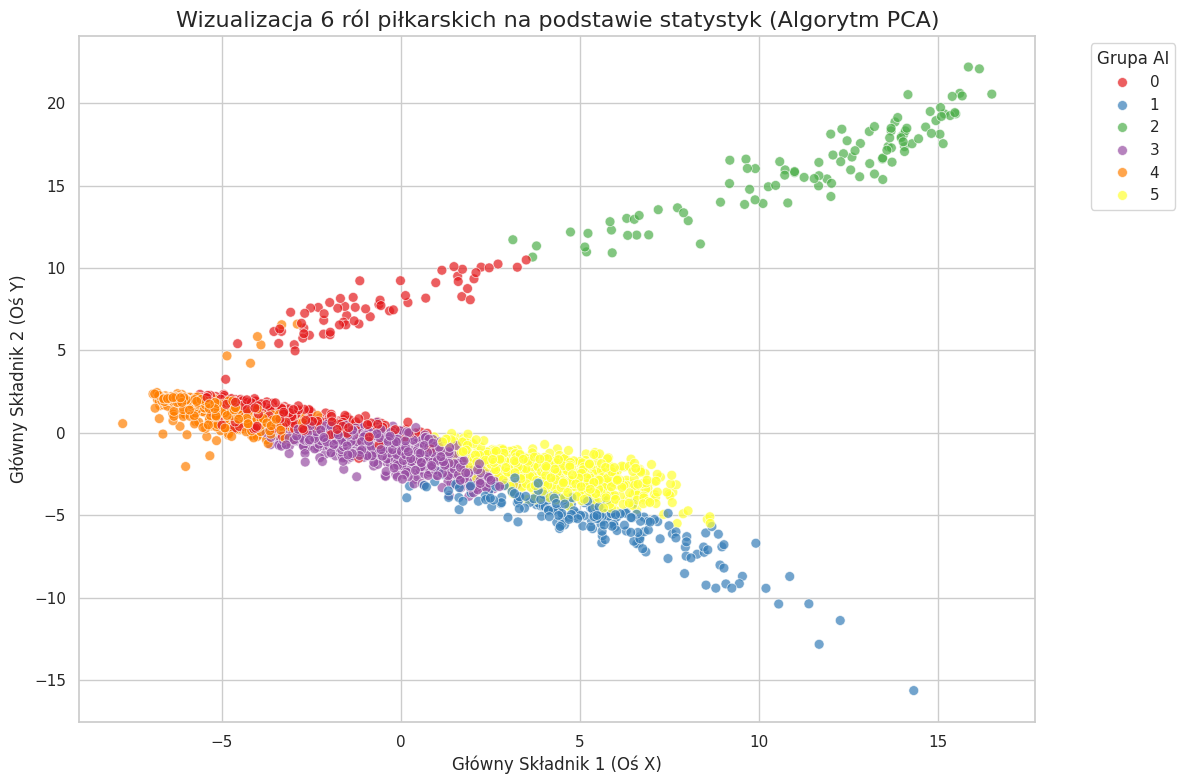

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tworzę algorytm PCA i ustawiam kompresję do 2 wymiarów
pca = PCA(n_components=2, random_state=42)


dane_pca = pca.fit_transform(dane_znormalizowane)


tabela_pilkarze['PCA_X'] = dane_pca[:, 0]
tabela_pilkarze['PCA_Y'] = dane_pca[:, 1]


plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA_X',
    y='PCA_Y',
    hue='Rola_AI',
    palette='Set1',
    data=tabela_pilkarze,
    alpha=0.7,
    s=50
)


plt.title('Wizualizacja 6 ról piłkarskich na podstawie statystyk (Algorytm PCA)', fontsize=16)
plt.xlabel('Główny Składnik 1 (Oś X)', fontsize=12)
plt.ylabel('Główny Składnik 2 (Oś Y)', fontsize=12)


plt.legend(title='Grupa AI', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

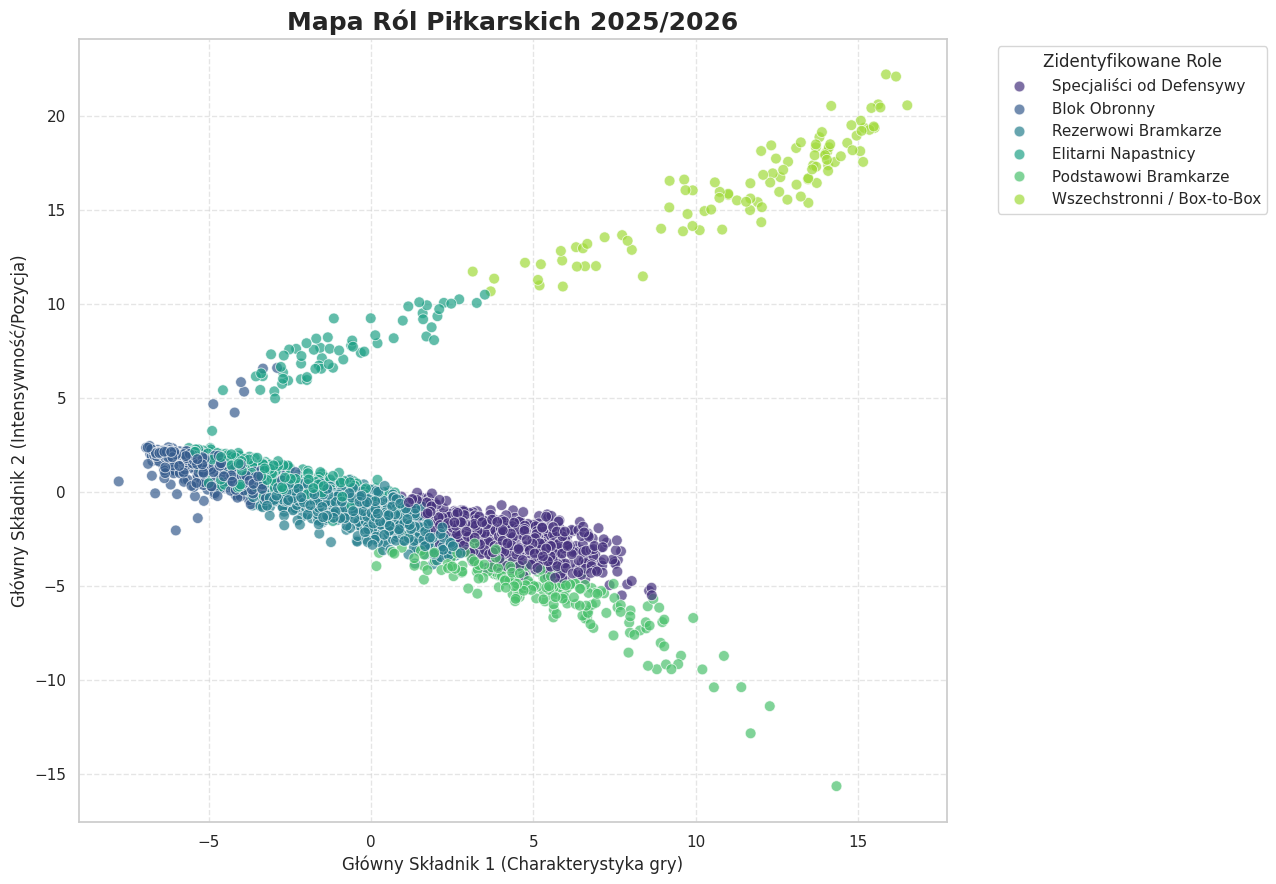

In [37]:
# 1. Tworzę słownik mapujący numery klastrów na ich nazwy
slownik_rol = {
    0: ' Elitarni Napastnicy',
    1: ' Podstawowi Bramkarze',
    2: ' Wszechstronni / Box-to-Box',
    3: ' Rezerwowi Bramkarze',
    4: ' Blok Obronny',
    5: ' Specjaliści od Defensywy'
}


tabela_pilkarze['Nazwa_Roli'] = tabela_pilkarze['Rola_AI'].map(slownik_rol)

import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(13, 9))
sns.scatterplot(
    x='PCA_X',
    y='PCA_Y',
    hue='Nazwa_Roli',
    palette='viridis',
    data=tabela_pilkarze,
    alpha=0.7,
    s=60
)


plt.title('Mapa Ról Piłkarskich 2025/2026', fontsize=18, fontweight='bold')
plt.xlabel('Główny Składnik 1 (Charakterystyka gry)', fontsize=12)
plt.ylabel('Główny Składnik 2 (Intensywność/Pozycja)', fontsize=12)

plt.legend(title='Zidentyfikowane Role', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()